In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import glob
import re
import os

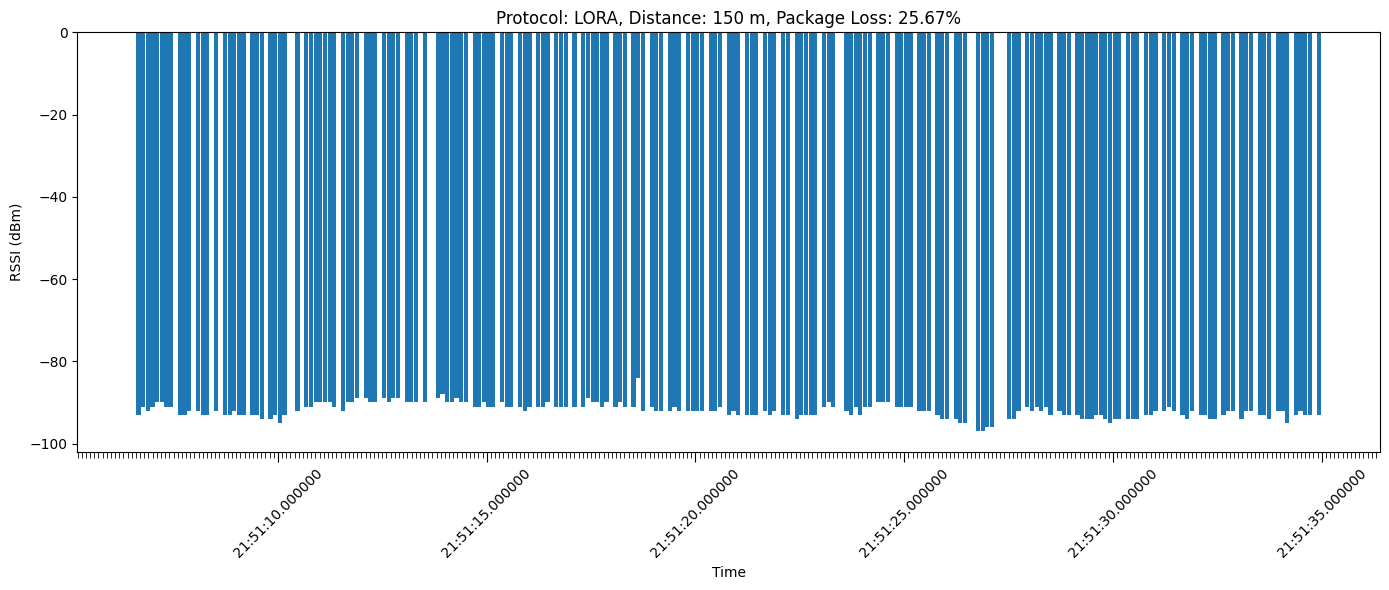

In [ ]:
file_name = "radio_raw_150.csv"

MAX_POINTS = 200
USE_LAST_POINTS = True

BAR_WIDTH_MS = 100          # Width of each packet column (ms)
MINOR_TICK_MS = 100       # Small tick every 100 ms

EXPECTED_PACKETS = 300

df = pd.read_csv(file_name)
df["timestamp"] = pd.to_datetime(df["timestamp"])
df = df.sort_values("timestamp")

received_packets = len(df)
packet_loss_pct = (1 - received_packets / EXPECTED_PACKETS) * 100

if MAX_POINTS is not None:
    df = df.tail(MAX_POINTS) if USE_LAST_POINTS else df.head(MAX_POINTS)

protocol = df["mode"].iloc[0]
distance = df["distance"].iloc[0]

fig, ax = plt.subplots(figsize=(14, 6))

bar_width = BAR_WIDTH_MS / (1000 * 60 * 60 * 24)

ax.bar(df["timestamp"], df["rssi"], width=bar_width)

ax.set_xlabel("Time")
ax.set_ylabel("RSSI (dBm)")
ax.set_title(f"Protocol: {protocol}, Distance: {distance} m, Package Loss: {packet_loss_pct:.2f}%")

ax.set_ylim(df["rssi"].min() - 5, 0)

ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S.%f'))

# Minor ticks every 100 ms (no labels)
minor_locator = mdates.MicrosecondLocator(interval=MINOR_TICK_MS * 1000)
ax.xaxis.set_minor_locator(minor_locator)

ax.tick_params(axis='x', which='minor', length=4)
ax.tick_params(axis='x', which='major', length=7)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

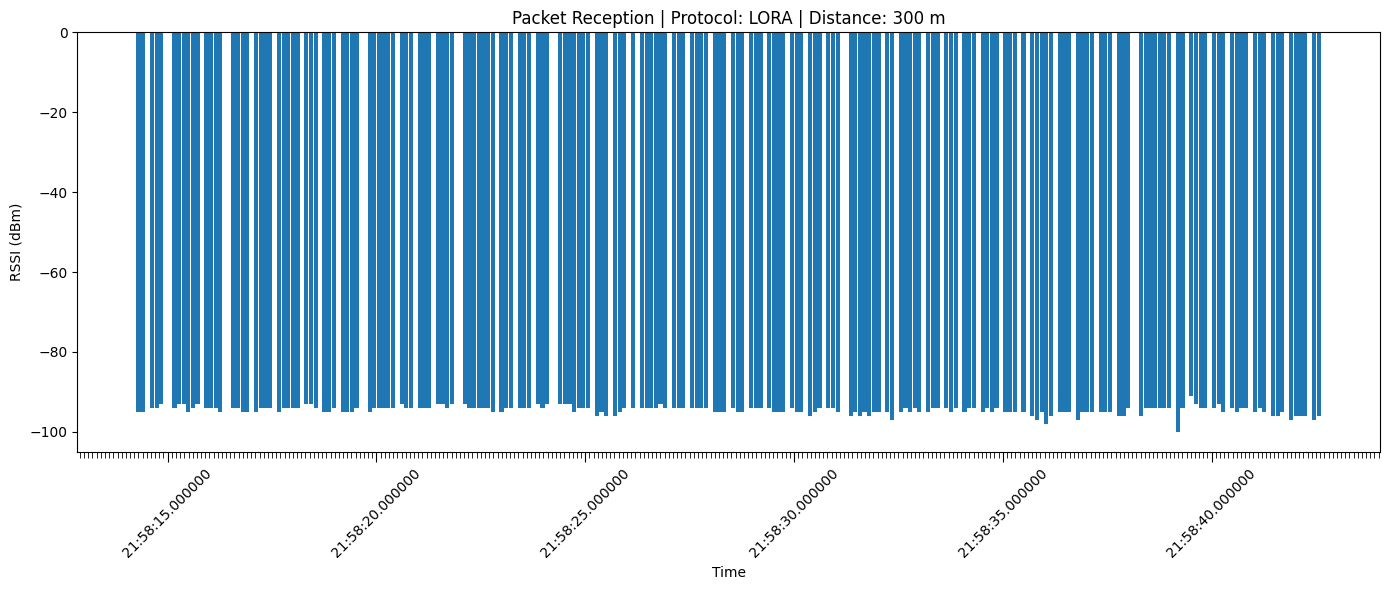

In [ ]:
file_name = "radio_raw_300.csv"

MAX_POINTS = 200
USE_LAST_POINTS = True

BAR_WIDTH_MS = 100          # Width of each packet column (ms)
MINOR_TICK_MS = 100       # Small tick every 100 ms

df = pd.read_csv(file_name)
df["timestamp"] = pd.to_datetime(df["timestamp"])
df = df.sort_values("timestamp")

if MAX_POINTS is not None:
    df = df.tail(MAX_POINTS) if USE_LAST_POINTS else df.head(MAX_POINTS)

protocol = df["mode"].iloc[0]
distance = df["distance"].iloc[0]

fig, ax = plt.subplots(figsize=(14, 6))

bar_width = BAR_WIDTH_MS / (1000 * 60 * 60 * 24)

ax.bar(df["timestamp"], df["rssi"], width=bar_width)

# Labels
ax.set_xlabel("Time")
ax.set_ylabel("RSSI (dBm)")
ax.set_title(f"Packet Reception | Protocol: {protocol} | Distance: {distance} m")

ax.set_ylim(df["rssi"].min() - 5, 0)

ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S.%f'))

minor_locator = mdates.MicrosecondLocator(interval=MINOR_TICK_MS * 1000)
ax.xaxis.set_minor_locator(minor_locator)

ax.tick_params(axis='x', which='minor', length=4)
ax.tick_params(axis='x', which='major', length=7)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

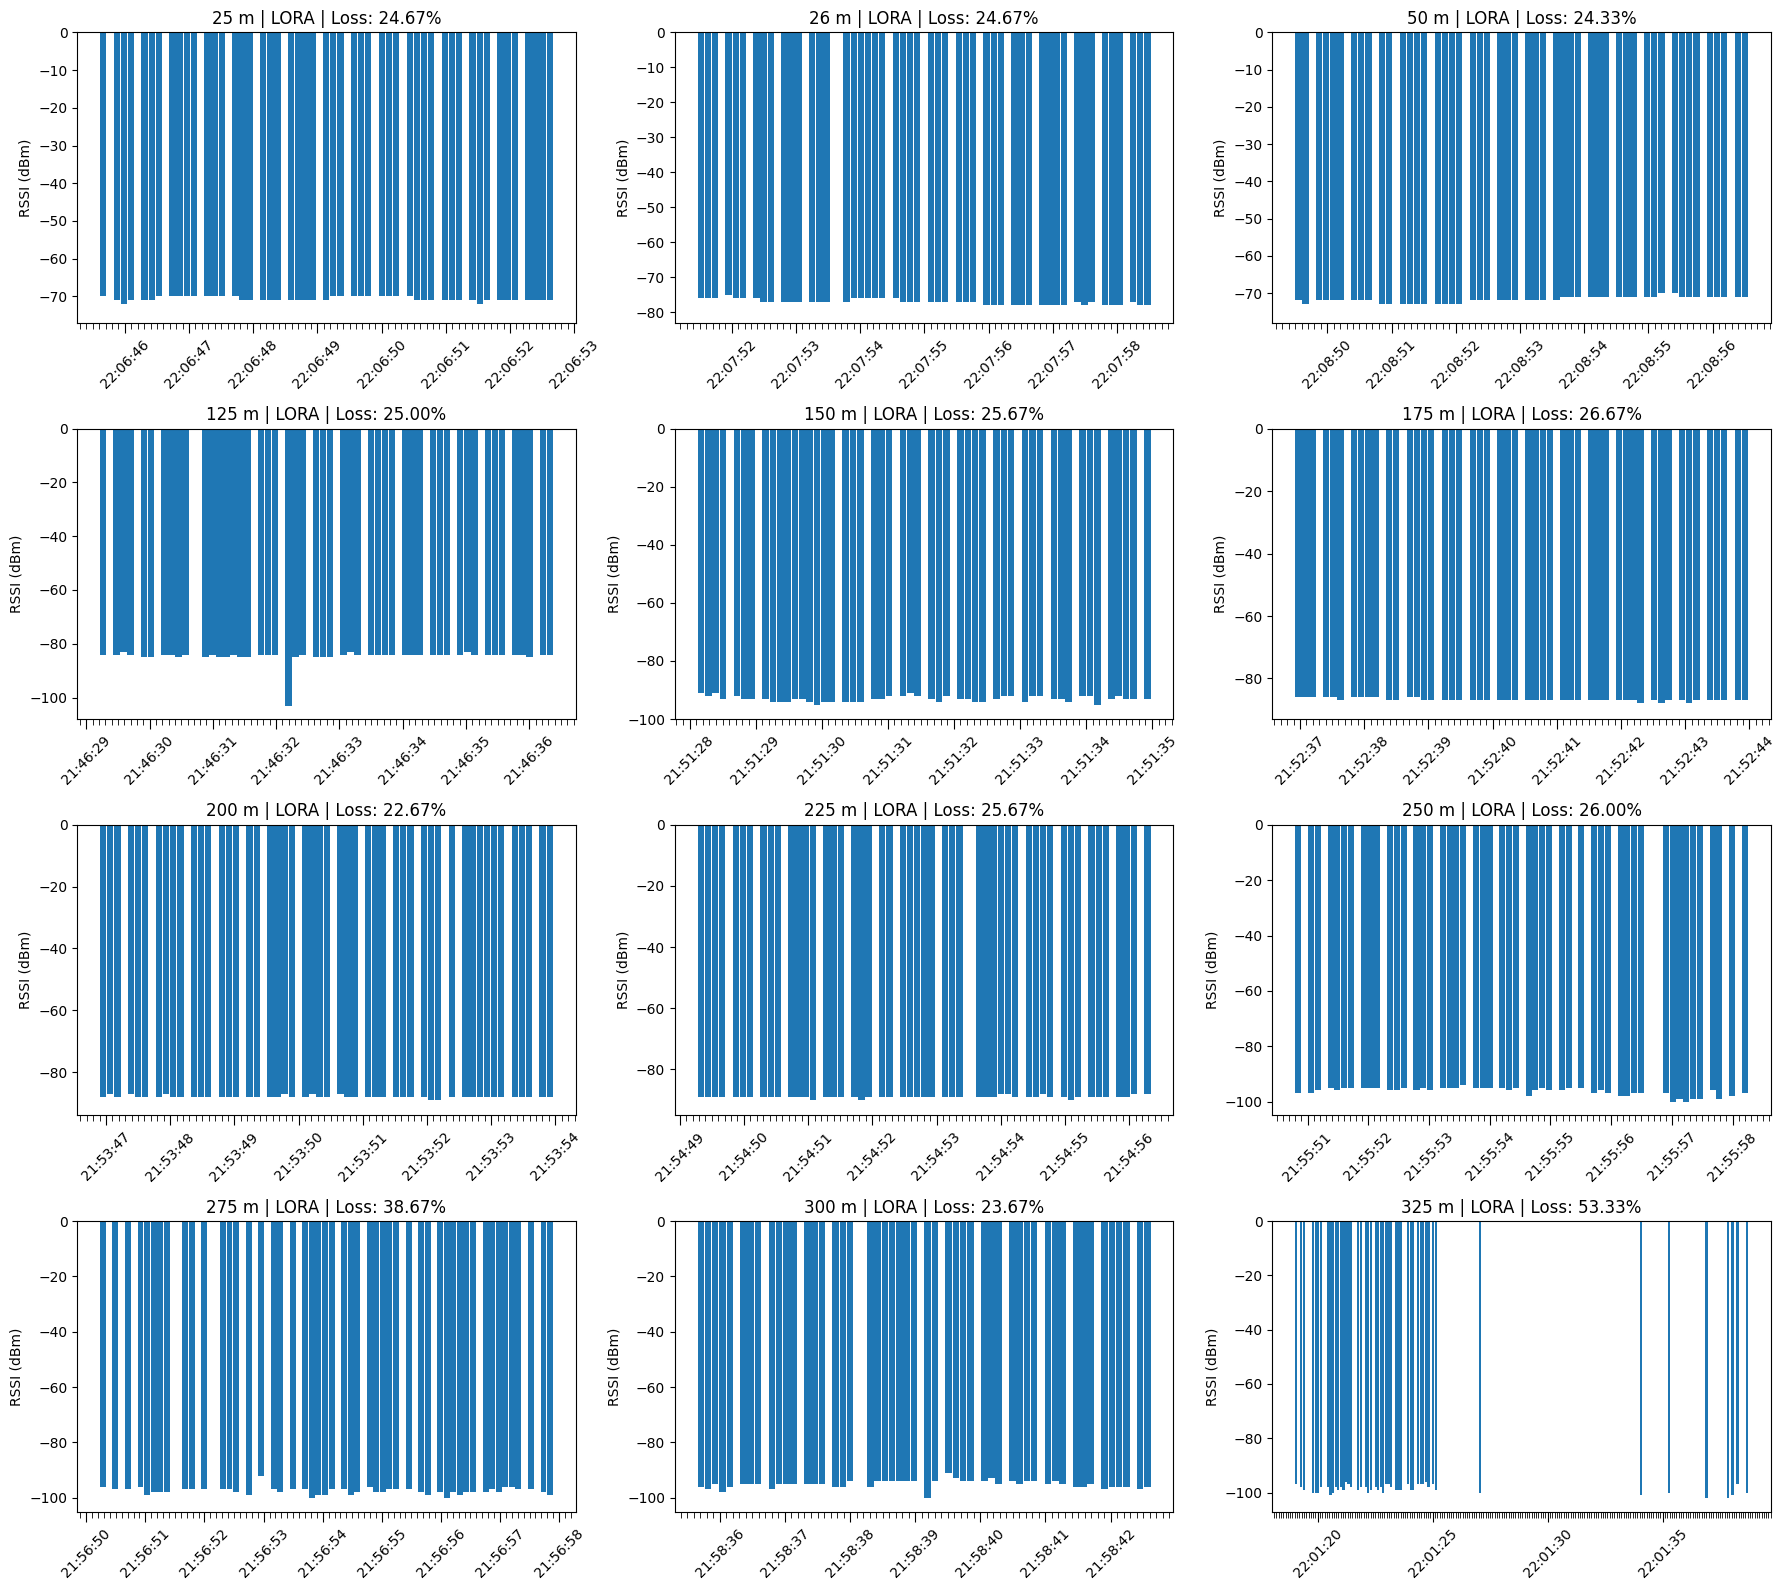

In [28]:
FILE_PATTERN = "radio_raw_*.csv"  # pattern to match all CSVs
MAX_POINTS = 50
USE_LAST_POINTS = True

BAR_WIDTH_MS = 100
MINOR_TICK_MS = 100
EXPECTED_PACKETS = 300

files = glob.glob(FILE_PATTERN)

def extract_distance(filename):
    m = re.search(r"radio_raw_(\d+)\.csv", os.path.basename(filename))
    return int(m.group(1)) if m else 0

# Sort files by distance
files = sorted(files, key=extract_distance)


num_files = len(files)
cols = 3  # number of plots per row
rows = (num_files + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(cols*6, rows*4), squeeze=False)


for idx, file_name in enumerate(files):
    row, col = divmod(idx, cols)
    ax = axes[row][col]

    # Load CSV
    df = pd.read_csv(file_name)
    df["timestamp"] = pd.to_datetime(df["timestamp"])
    df = df.sort_values("timestamp")

    # Compute packet loss
    received_packets = len(df)
    packet_loss_pct = (1 - received_packets / EXPECTED_PACKETS) * 100

    # Take limited points
    if MAX_POINTS is not None:
        df = df.tail(MAX_POINTS) if USE_LAST_POINTS else df.head(MAX_POINTS)

    protocol = df["mode"].iloc[0]
    distance = df["distance"].iloc[0]

    bar_width = BAR_WIDTH_MS / (1000 * 60 * 60 * 24)

    ax.bar(df["timestamp"], df["rssi"], width=bar_width)

    ax.set_title(f"{distance} m | {protocol} | Loss: {packet_loss_pct:.2f}%")
    ax.set_ylabel("RSSI (dBm)")

    ax.set_ylim(df["rssi"].min() - 5, 0)

    ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))
    minor_locator = mdates.MicrosecondLocator(interval=MINOR_TICK_MS * 1000)
    ax.xaxis.set_minor_locator(minor_locator)
    ax.tick_params(axis='x', which='minor', length=4)
    ax.tick_params(axis='x', which='major', length=7)
    ax.tick_params(axis='x', labelrotation=45)

# Hide empty subplots if any
for i in range(idx + 1, rows*cols):
    row, col = divmod(i, cols)
    axes[row][col].axis('off')

plt.tight_layout()
plt.show()

133


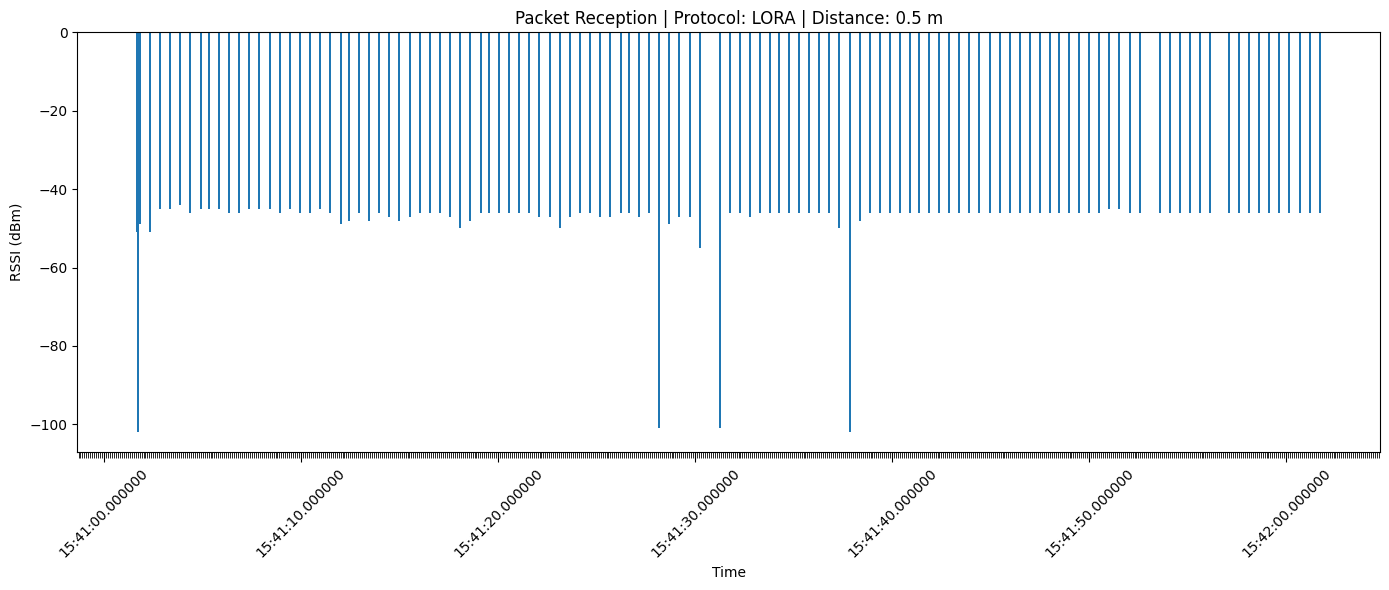

In [4]:
file_name = "radio_raw_0.5.csv"

MAX_POINTS = 120
USE_LAST_POINTS = True

BAR_WIDTH_MS = 100          # Width of each packet column (ms)
MINOR_TICK_MS = 100       # Small tick every 100 ms

df = pd.read_csv(file_name)
df["timestamp"] = pd.to_datetime(df["timestamp"])
df = df.sort_values("timestamp")
print(len(df))

if MAX_POINTS is not None:
    df = df.tail(MAX_POINTS) if USE_LAST_POINTS else df.head(MAX_POINTS)

protocol = df["mode"].iloc[0]
distance = df["distance"].iloc[0]

fig, ax = plt.subplots(figsize=(14, 6))

bar_width = BAR_WIDTH_MS / (1000 * 60 * 60 * 24)

ax.bar(df["timestamp"], df["rssi"], width=bar_width)

# Labels
ax.set_xlabel("Time")
ax.set_ylabel("RSSI (dBm)")
ax.set_title(f"Packet Reception | Protocol: {protocol} | Distance: {distance} m")

ax.set_ylim(df["rssi"].min() - 5, 0)

ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S.%f'))

minor_locator = mdates.MicrosecondLocator(interval=MINOR_TICK_MS * 1000)
ax.xaxis.set_minor_locator(minor_locator)

ax.tick_params(axis='x', which='minor', length=4)
ax.tick_params(axis='x', which='major', length=7)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()